In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def get_belgium_summary(df):
    # Mean / Median toàn quốc
    mean_m2 = round(df["price_per_m2"].mean())
    median_m2 = round(df["price_per_m2"].median())

    # Stats theo city
    city_stats = (
        df.groupby("city")
        .agg(
            total_price=("price", "sum"),
            total_surface=("livable_surface", "sum")
        )
        .reset_index()
    )

    city_stats["weighted_mean_m2"] = (
        city_stats["total_price"] /
        city_stats["total_surface"]
    )

    max_city = city_stats.loc[
        city_stats["weighted_mean_m2"].idxmax()
    ]

    min_city = city_stats.loc[
        city_stats["weighted_mean_m2"].idxmin()
    ]

    return pd.DataFrame([{
        "region": "Belgium",
        "mean": int(mean_m2),
        "median": int(median_m2),
        "min_city": min_city["city"],
        "m2_min": int(round(min_city["weighted_mean_m2"])),
        "max_city": max_city["city"],
        "m2_max": int(round(max_city["weighted_mean_m2"]))
    }])

def draw_dashboard(df):
    summary = df.groupby("region", as_index=False).agg(
        mean=("price_per_m2", "mean"),
        median=("price_per_m2", "median")
    )

    city_stats = (
        df.groupby(["region", "city"])
        .agg(
            total_price=("price", "sum"),
            total_surface=("livable_surface", "sum"),
            median_m2=("price_per_m2", "median"),
            count=("price_per_m2", "size")
        )
        .reset_index()
    )

    city_stats["weighted_mean_m2"] = (
        city_stats["total_price"] /
        city_stats["total_surface"]
    )
    max_df = city_stats.loc[
        city_stats.groupby("region")["weighted_mean_m2"].idxmax()
    ].copy()

    min_df = city_stats.loc[
        city_stats.groupby("region")["weighted_mean_m2"].idxmin()
    ].copy()

    max_df = max_df.rename(columns={
        "city": "max_city",
        "weighted_mean_m2": "m2_max"
    })

    min_df = min_df.rename(columns={
        "city": "min_city",
        "weighted_mean_m2": "m2_min"
    })
    min_df = min_df[
        ["region", "min_city", "m2_min"]
    ]

    max_df = max_df[
        ["region", "max_city", "m2_max"]
    ]
    
    summary = summary.merge(min_df, on="region")
    summary = summary.merge(max_df, on="region")
    summary[["mean", "median", "m2_min", "m2_max"]] = summary[
        ["mean", "median", "m2_min", "m2_max"]
    ].round(0).astype(int)

    belgium_summary = get_belgium_summary(df)
    summary = pd.concat(
        [summary, belgium_summary],
        ignore_index=True
    )
    # order = ["Flanders", "Wallonia", "Brussels", "Belgium"]

    # summary["region"] = pd.Categorical(
    #     summary["region"],
    #     categories=order,
    #     ordered=True
    # )

    summary = summary.sort_values("region").reset_index(drop=True)

    print(summary)

    # =========================================================
    # PLOT
    # =========================================================
    x = np.arange(len(summary))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10,6))

    # BAR
    bars_min = ax.bar(x - width/2, summary["m2_min"], width, color="lightblue", label="€/m² Weighted Min")
    bars_max = ax.bar(x + width/2, summary["m2_max"], width, color="steelblue", label="€/m² Weighted Max")

    # LINE
    ax.plot(x, summary["mean"], marker="o", color="green", label="Mean €/m²")
    ax.plot(x, summary["median"], marker="o", color="red", label="Median €/m²")

    # -----------------------
    # LABEL MIN CITY + VALUE
    # -----------------------
    for i in range(len(summary)):
        ax.text(
            x[i] - width/2,
            summary["m2_min"][i] / 2,
            f'{summary["min_city"][i]}\n{summary["m2_min"][i]}',
            ha="center",
            va="center",
            fontsize=8
        )

        ax.text(
            x[i] + width/2,
            summary["m2_max"][i] / 2,
            f'{summary["max_city"][i]}\n{summary["m2_max"][i]}',
            ha="center",
            va="center",
            fontsize=8,
            color="white"
        )

    # LINE LABELS
    for i in range(len(summary)):
        ax.text(x[i], summary["mean"][i] + 80, summary["mean"][i], ha="center", color="green", fontsize=8)
        ax.text(x[i], summary["median"][i] - 120, summary["median"][i], ha="center", color="red", fontsize=8)

    # FORMAT
    ax.set_xticks(x)
    ax.set_xticklabels(summary["region"])

    ax.set_title("€/m² Price Distribution with Min/Max Cities")
    ax.set_ylabel("€/m²")

    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

In [2]:

GEO_DATA = {
    "bruxelles": {
        "name": "Bruxelles-Capitale", 
        "provinces": ["brussels"]},
    "flandre": {
        "name": "Flandre", 
        "provinces": [
            "antwerp", 
            "limburg", 
            "east-flanders", 
            "vlaams-brabant", 
            "west-flanders"]},
    "wallonie": {
        "name": "Wallonie", 
        "provinces": [
            "hainaut", 
            "liege", 
            "luxembourg", 
            "namur", 
            "brabant-wallon"]}
}

def clean_data(df):
    df = df.copy()

    # 1. convert FIRST (quan trọng)
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["livable_surface"] = pd.to_numeric(df["livable_surface"], errors="coerce")

    # 2. remove missing
    df = df.dropna(subset=["price", "livable_surface", "province"])

    # 3. remove invalid values
    df = df[(df["price"] > 0) & (df["livable_surface"] > 10)]

    # 4. compute feature
    df["price_per_m2"] = df["price"] / df["livable_surface"]

    # 6. normalize text
    df["province"] = df["province"].str.lower()
    df = df.groupby("city").filter(lambda x: len(x) >= 10)
    return df

def province_to_region(df):
    province_to_region = {
        province.lower(): region
        for region, info in GEO_DATA.items()
        for province in info["provinces"]
    }
    df["region"] = df["province"].map(province_to_region)
    return df


def compute_metrics(df):
    # Weighted price per m² (MOST IMPORTANT - market truth)
    weighted = (
        df.groupby("region")[["price", "livable_surface"]]
        .sum()
        .eval("price / livable_surface")
        .sort_values(ascending=False)
    )

    count = df["region"].value_counts()


    return weighted, count

      region  mean  median             min_city  m2_min             max_city  \
0    Belgium  3161    2635               Mettet     730             Cheratte   
1  bruxelles  3983    3635  Sint-Jans-Molenbeek    2281  Sint-Pieters-Woluwe   
2    flandre  3147    2794               Wervik    1262         Knokke-Heist   
3   wallonie  2880    2128               Mettet     730             Cheratte   

   m2_max  
0   11381  
1    4984  
2    9820  
3   11381  


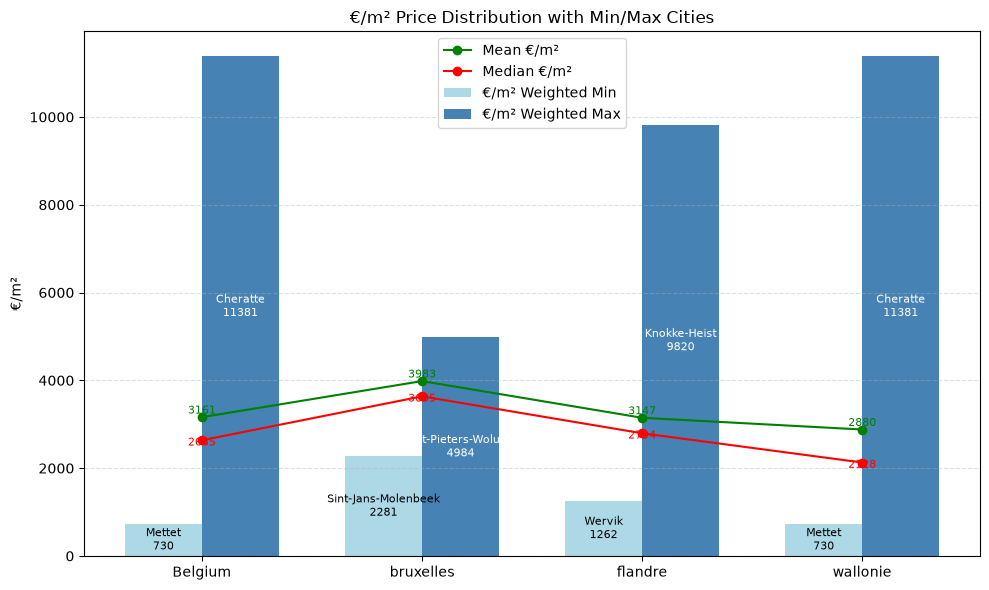

In [3]:
df = pd.read_json("../../data/cleaned/clean_dataframe_fixed.json")

df_clean = clean_data(df)
df_clean = province_to_region(df_clean) 
weighted, count = compute_metrics(df_clean)
draw_dashboard(df_clean)

In [4]:
heverlee = df[df["city"].str.lower() == "heverlee"]

print(heverlee[["city", "price", "livable_surface"]])

          city    price  livable_surface
3452  Heverlee    85000             55.0
3464  Heverlee   195000             23.0
3473  Heverlee   195000             22.0
3499  Heverlee    99000             55.0
3515  Heverlee    95000             55.0
3518  Heverlee    99000             55.0
3525  Heverlee   199000             29.0
3534  Heverlee   155000             56.0
3639  Heverlee   275000             55.0
3694  Heverlee   297000             52.0
3744  Heverlee   215000             38.0
3900  Heverlee   370000             62.0
3905  Heverlee   355000             49.0
3912  Heverlee   375000             58.0
4038  Heverlee   690000            168.0
4174  Heverlee   545000            150.0
4266  Heverlee   625000            145.0
4287  Heverlee   575000            235.0
4293  Heverlee   640000            163.0
4360  Heverlee   575000            124.0
4398  Heverlee   595000            110.0
4488  Heverlee   546000             62.0
4502  Heverlee   635000            115.0
4505  Heverlee  

      region         mean       median             min_city       m2_min  \
0    Belgium  3161.000000  2635.000000               Mettet   730.000000   
1  bruxelles  3982.620783  3635.489510  Sint-Jans-Molenbeek  2280.842298   
2    flandre  3146.973860  2794.326241               Wervik  1262.162162   
3   wallonie  2880.324529  2128.205128               Mettet   729.653882   

              max_city        m2_max  
0             Cheratte  11381.000000  
1  Sint-Pieters-Woluwe   4984.066236  
2         Knokke-Heist   9819.704786  
3             Cheratte  11381.102136  


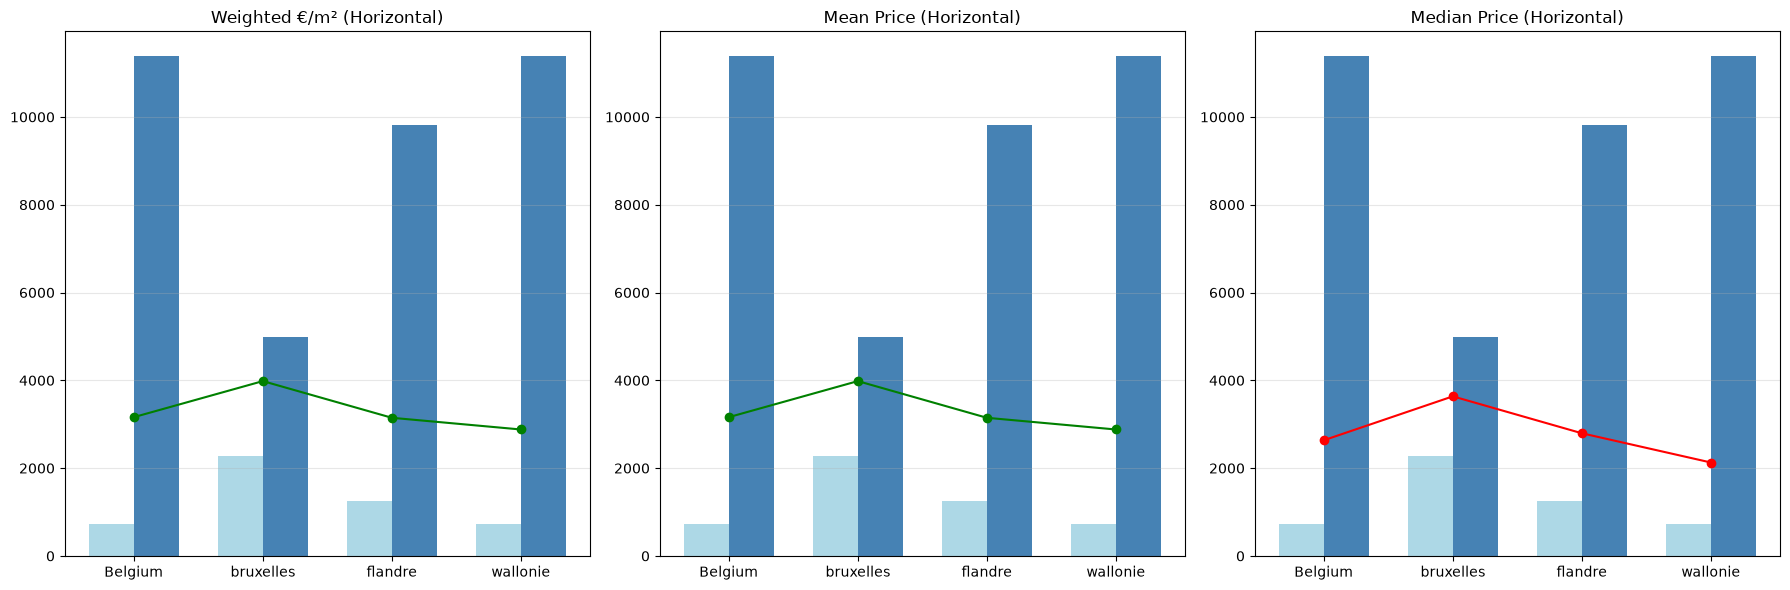

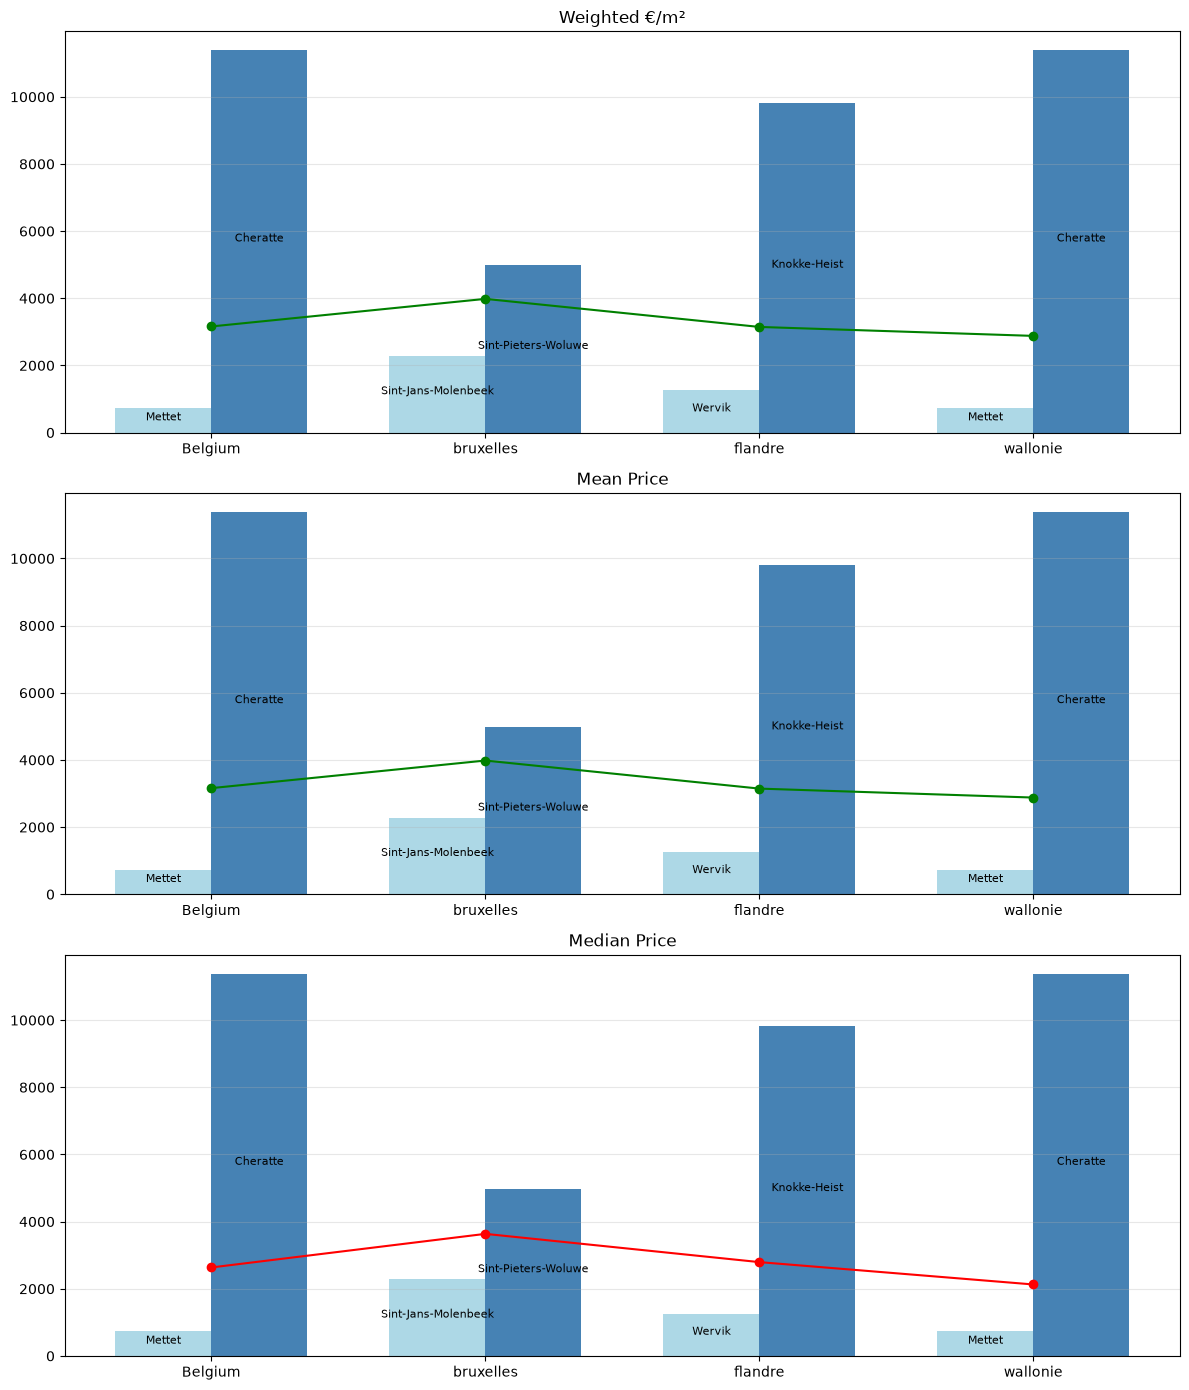

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# BELGIUM SUMMARY
# =========================================================
def get_belgium_summary(df):
    mean_m2 = round(df["price_per_m2"].mean())
    median_m2 = round(df["price_per_m2"].median())

    city_stats = (
        df.groupby("city")
        .agg(
            total_price=("price", "sum"),
            total_surface=("livable_surface", "sum")
        )
        .reset_index()
    )

    city_stats["weighted_mean_m2"] = (
        city_stats["total_price"] / city_stats["total_surface"]
    )

    max_city = city_stats.loc[city_stats["weighted_mean_m2"].idxmax()]
    min_city = city_stats.loc[city_stats["weighted_mean_m2"].idxmin()]

    return pd.DataFrame([{
        "region": "Belgium",
        "mean": int(mean_m2),
        "median": int(median_m2),
        "min_city": min_city["city"],
        "m2_min": int(round(min_city["weighted_mean_m2"])),
        "max_city": max_city["city"],
        "m2_max": int(round(max_city["weighted_mean_m2"]))
    }])


# =========================================================
# MAIN
# =========================================================
def draw_dashboard(df):

    # -------------------------
    # REGION STATS
    # -------------------------
    summary = df.groupby("region", as_index=False).agg(
        mean=("price_per_m2", "mean"),
        median=("price_per_m2", "median")
    )

    # -------------------------
    # CITY STATS
    # -------------------------
    city_stats = (
        df.groupby(["region", "city"])
        .agg(
            total_price=("price", "sum"),
            total_surface=("livable_surface", "sum")
        )
        .reset_index()
    )

    city_stats["weighted_mean_m2"] = (
        city_stats["total_price"] / city_stats["total_surface"]
    )

    max_df = city_stats.loc[
        city_stats.groupby("region")["weighted_mean_m2"].idxmax()
    ][["region", "city", "weighted_mean_m2"]]

    min_df = city_stats.loc[
        city_stats.groupby("region")["weighted_mean_m2"].idxmin()
    ][["region", "city", "weighted_mean_m2"]]

    max_df = max_df.rename(columns={"city": "max_city", "weighted_mean_m2": "m2_max"})
    min_df = min_df.rename(columns={"city": "min_city", "weighted_mean_m2": "m2_min"})

    summary = summary.merge(min_df, on="region")
    summary = summary.merge(max_df, on="region")

    # -------------------------
    # BELGIUM ROW
    # -------------------------
    summary = pd.concat([summary, get_belgium_summary(df)], ignore_index=True)

    summary = summary.sort_values("region").reset_index(drop=True)

    print(summary)

    x = np.arange(len(summary))
    width = 0.35



    # =========================================================
    # FIGURE 1 — HORIZONTAL
    # =========================================================
    fig2, axes = plt.subplots(1, 3, figsize=(18, 6))

    # chart 1
    axes[0].bar(x - width/2, summary["m2_min"], width, color="lightblue")
    axes[0].bar(x + width/2, summary["m2_max"], width, color="steelblue")
    axes[0].plot(x, summary["mean"], marker="o", color="green")
    axes[0].set_title("Weighted €/m² (Horizontal)")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(summary["region"])
    axes[0].grid(axis="y", alpha=0.3)

    # chart 2
    axes[1].bar(x - width/2, summary["m2_min"], width, color="lightblue")
    axes[1].bar(x + width/2, summary["m2_max"], width, color="steelblue")
    axes[1].plot(x, summary["mean"], marker="o", color="green")
    axes[1].set_title("Mean Price (Horizontal)")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(summary["region"])
    axes[1].grid(axis="y", alpha=0.3)

    # chart 3
    axes[2].bar(x - width/2, summary["m2_min"], width, color="lightblue")
    axes[2].bar(x + width/2, summary["m2_max"], width, color="steelblue")
    axes[2].plot(x, summary["median"], marker="o", color="red")
    axes[2].set_title("Median Price (Horizontal)")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(summary["region"])
    axes[2].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    # =========================================================
    # FIGURE 2 — VERTICAL
    # =========================================================
    fig1, axes = plt.subplots(3, 1, figsize=(12, 14))

    def add_city_labels(ax):
        for i in range(len(summary)):
            ax.text(x[i] - width/2, summary["m2_min"][i]/2,
                    summary["min_city"][i],
                    ha="center", fontsize=8)

            ax.text(x[i] + width/2, summary["m2_max"][i]/2,
                    summary["max_city"][i],
                    ha="center", fontsize=8)

    # 1
    axes[0].bar(x - width/2, summary["m2_min"], width, color="lightblue")
    axes[0].bar(x + width/2, summary["m2_max"], width, color="steelblue")
    axes[0].plot(x, summary["mean"], marker="o", color="green")
    axes[0].set_title("Weighted €/m²")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(summary["region"])
    axes[0].grid(axis="y", alpha=0.3)
    add_city_labels(axes[0])

    # 2
    axes[1].bar(x - width/2, summary["m2_min"], width, color="lightblue")
    axes[1].bar(x + width/2, summary["m2_max"], width, color="steelblue")
    axes[1].plot(x, summary["mean"], marker="o", color="green")
    axes[1].set_title("Mean Price")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(summary["region"])
    axes[1].grid(axis="y", alpha=0.3)
    add_city_labels(axes[1])

    # 3
    axes[2].bar(x - width/2, summary["m2_min"], width, color="lightblue")
    axes[2].bar(x + width/2, summary["m2_max"], width, color="steelblue")
    axes[2].plot(x, summary["median"], marker="o", color="red")
    axes[2].set_title("Median Price")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(summary["region"])
    axes[2].grid(axis="y", alpha=0.3)
    add_city_labels(axes[2])

    plt.tight_layout()
    plt.show()

GEO_DATA = {
    "bruxelles": {
        "name": "Bruxelles-Capitale", 
        "provinces": ["brussels"]},
    "flandre": {
        "name": "Flandre", 
        "provinces": [
            "antwerp", 
            "limburg", 
            "east-flanders", 
            "vlaams-brabant", 
            "west-flanders"]},
    "wallonie": {
        "name": "Wallonie", 
        "provinces": [
            "hainaut", 
            "liege", 
            "luxembourg", 
            "namur", 
            "brabant-wallon"]}
}

def clean_data(df):
    df = df.copy()

    # 1. convert FIRST (quan trọng)
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["livable_surface"] = pd.to_numeric(df["livable_surface"], errors="coerce")

    # 2. remove missing
    df = df.dropna(subset=["price", "livable_surface", "province"])

    # 3. remove invalid values
    df = df[(df["price"] > 0) & (df["livable_surface"] > 10)]

    # 4. compute feature
    df["price_per_m2"] = df["price"] / df["livable_surface"]

    # 6. normalize text
    df["province"] = df["province"].str.lower()
    df = df.groupby("city").filter(lambda x: len(x) >= 10)
    return df

def province_to_region(df):
    province_to_region = {
        province.lower(): region
        for region, info in GEO_DATA.items()
        for province in info["provinces"]
    }
    df["region"] = df["province"].map(province_to_region)
    return df


def compute_metrics(df):
    # Weighted price per m² (MOST IMPORTANT - market truth)
    weighted = (
        df.groupby("region")[["price", "livable_surface"]]
        .sum()
        .eval("price / livable_surface")
        .sort_values(ascending=False)
    )

    count = df["region"].value_counts()


    return weighted, count

df = pd.read_json("../../data/cleaned/clean_dataframe_fixed.json")

df_clean = clean_data(df)
df_clean = province_to_region(df_clean) 
weighted, count = compute_metrics(df_clean)
draw_dashboard(df_clean)s